In [23]:
# 1) Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

#  2) Load dataset 
df = pd.read_csv("D:\Projects\Retinopathy\P653_pronostico_dataset - P653_pronostico_dataset.csv")

# First few rows
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [24]:
# 3) Basic Dataset Information
print("Shape:", df.shape)

print("\nColumns:\n", df.columns)

df.info()

Shape: (6000, 6)

Columns:
 Index(['ID', 'age', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'prognosis'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [25]:
# 4) Drop ID only if it exists, otherwise ignore.
df = df.drop(columns=['ID'], errors='ignore')
df

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,78.346286,109.154591,90.713220,92.511770,retinopathy
...,...,...,...,...,...
5995,49.611850,94.857639,86.615671,107.643986,no_retinopathy
5996,63.099686,100.039527,93.515186,104.971404,retinopathy
5997,55.562243,98.421446,102.697875,120.875951,retinopathy
5998,63.468956,106.809289,88.060631,106.052213,retinopathy


In [26]:
# 5) Convert Target to Numeric
df["prognosis"] = df["prognosis"].map({
    "no_retinopathy": 0,
    "retinopathy": 1
})
df

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,1
1,63.529850,99.379736,84.852361,110.382411,1
2,69.003986,111.349455,109.850616,100.828246,1
3,82.638210,95.056128,79.666851,87.066303,1
4,78.346286,109.154591,90.713220,92.511770,1
...,...,...,...,...,...
5995,49.611850,94.857639,86.615671,107.643986,0
5996,63.099686,100.039527,93.515186,104.971404,1
5997,55.562243,98.421446,102.697875,120.875951,1
5998,63.468956,106.809289,88.060631,106.052213,1


In [27]:
# 6) Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)
df = df.dropna()


Missing Values:
 age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64


In [28]:
# 7) Duplicate Rows Check (Missing)
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [29]:
# 8) Summary statistics for all columns
print(df.describe(include='all'))

# Transposed summary for numeric features (features as rows, stats as columns)
print(df['prognosis'].value_counts())


               age  systolic_bp  diastolic_bp  cholesterol    prognosis
count  6000.000000  6000.000000   6000.000000  6000.000000  6000.000000
mean     60.464121   100.694822     90.505547   100.628255     0.514500
std       8.564392    10.669267      9.648200    10.433915     0.499831
min      35.164761    69.675429     62.807105    69.967453     0.000000
25%      54.371941    93.267420     83.641788    93.202373     0.000000
50%      59.831159   100.119926     89.912429   100.060637     1.000000
75%      65.809652   107.439501     96.682405   107.250829     1.000000
max     103.279497   151.699660    133.456382   148.233544     1.000000
prognosis
1    3087
0    2913
Name: count, dtype: int64


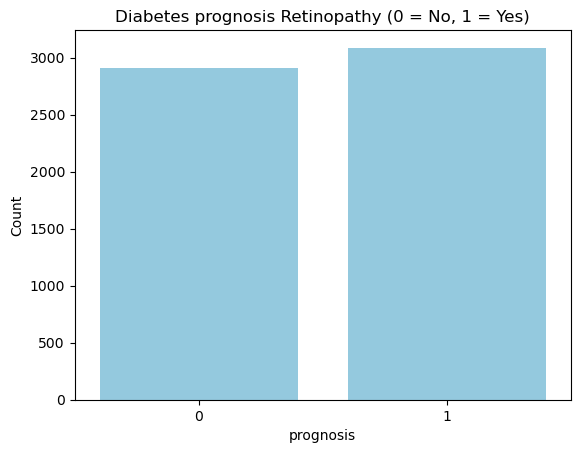

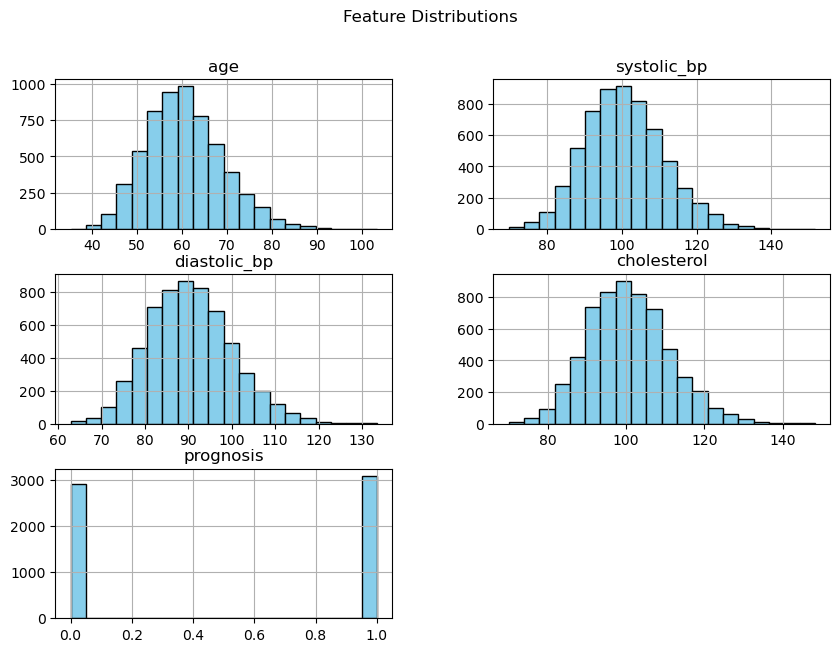

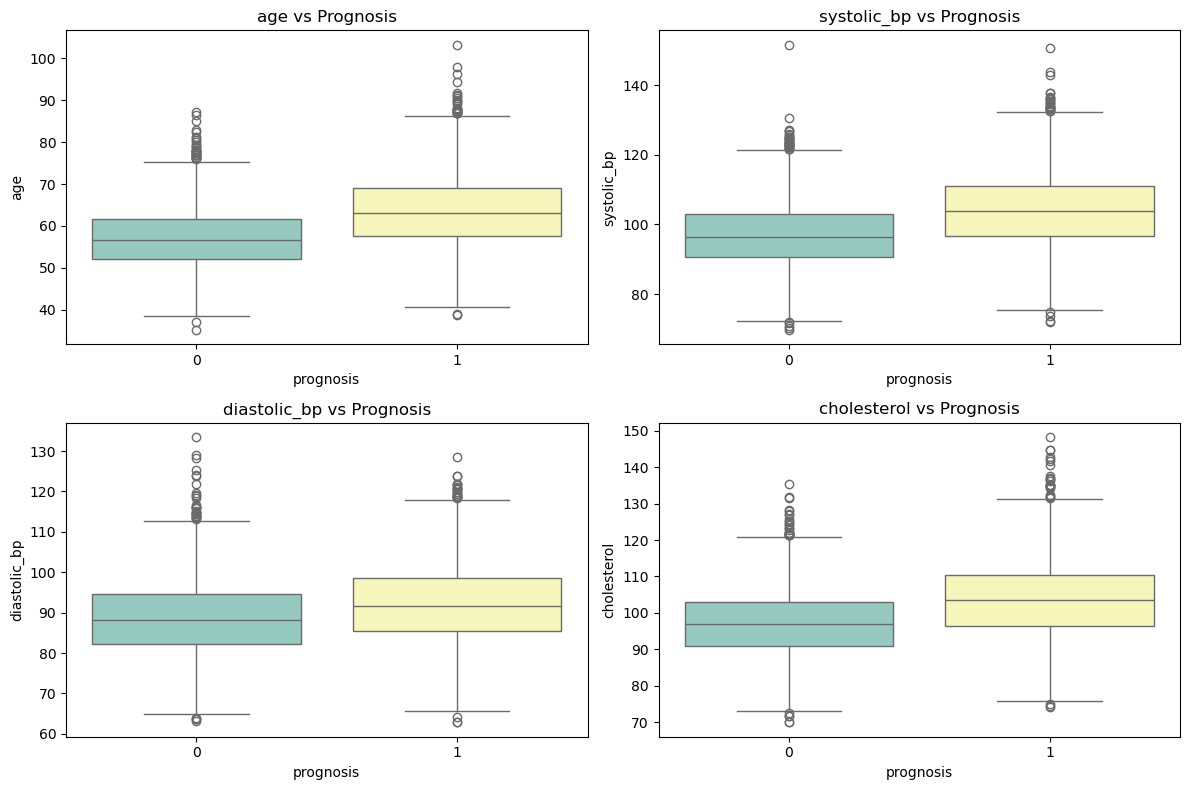

In [30]:
# 9) Distribution of target variable (prognosis)
sns.countplot(x='prognosis', data=df, color='Skyblue')
plt.title("Diabetes prognosis Retinopathy (0 = No, 1 = Yes)")
plt.xlabel("prognosis")
plt.ylabel("Count")
plt.show()


# 10) Numeric distribution helps understand how each variable is spread like skewed data,normal distribution,outliers)
df.hist(figsize=(10,7), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()

# 11)  Boxplots for each feature vs prognosis 
features = ['age','systolic_bp','diastolic_bp','cholesterol']

plt.figure(figsize=(12,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(
        x='prognosis',
        y=feature,
        hue='prognosis',
        data=df,
        palette='Set3',
        legend=False
    )
    plt.title(f"{feature} vs Prognosis")

plt.tight_layout()
plt.show()

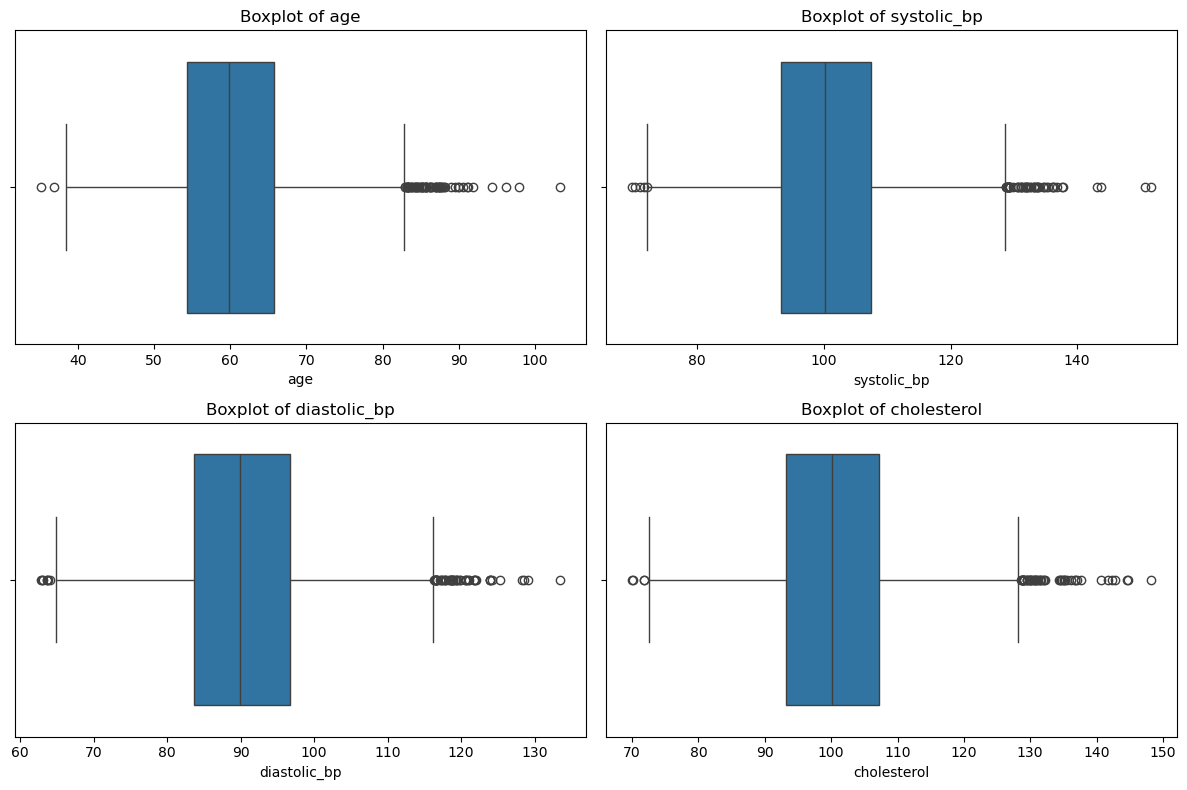

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age','systolic_bp','diastolic_bp','cholesterol']

plt.figure(figsize=(12,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [32]:
# Cap using IQR (insted of removing)
for col in ['age','systolic_bp','diastolic_bp','cholesterol']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # count outliers
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    # remaining values
    remaining = len(df[col]) - outliers

    # capping
    df[col] = df[col].clip(lower, upper)

    print(f"{col}: Found {outliers} outliers. Remaining {remaining}. Capping at {lower:.2f} and {upper:.2f}")
    print(df.shape)

age: Found 65 outliers. Remaining 5935. Capping at 37.22 and 82.97
(6000, 5)
systolic_bp: Found 55 outliers. Remaining 5945. Capping at 72.01 and 128.70
(6000, 5)
diastolic_bp: Found 55 outliers. Remaining 5945. Capping at 64.08 and 116.24
(6000, 5)
cholesterol: Found 54 outliers. Remaining 5946. Capping at 72.13 and 128.32
(6000, 5)


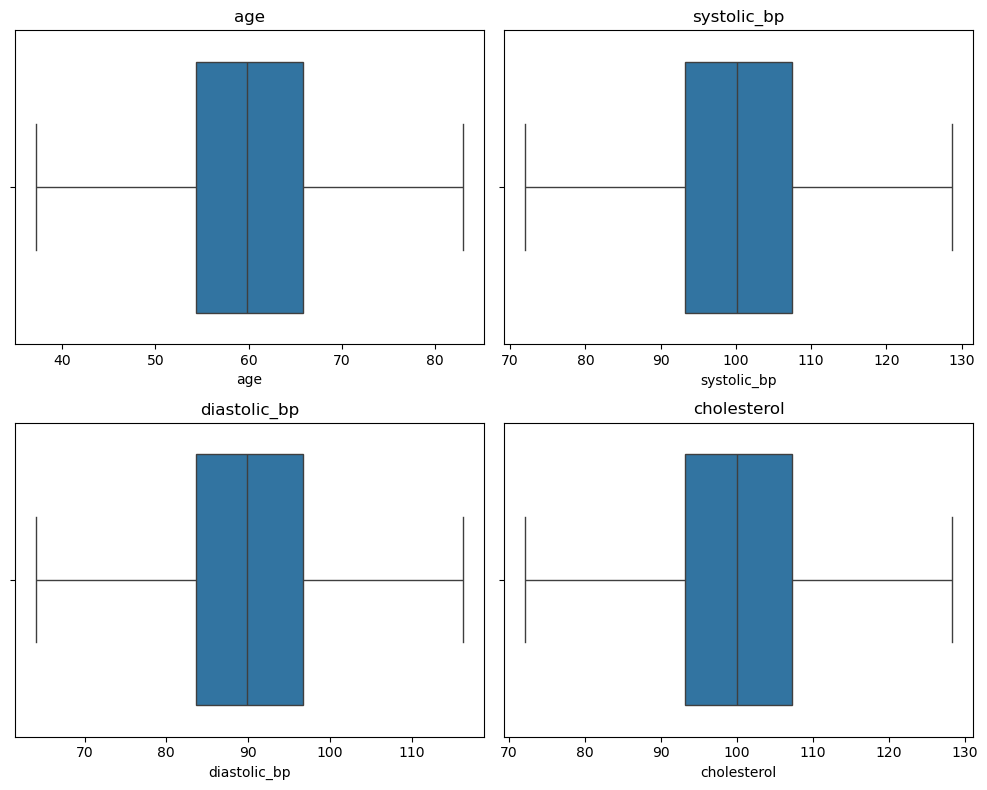

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age','systolic_bp','diastolic_bp','cholesterol']

fig, axes = plt.subplots(2, 2, figsize=(10,8))

for i, col in enumerate(cols):
    sns.boxplot(x=df[col], ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(col)

plt.tight_layout()
plt.show()

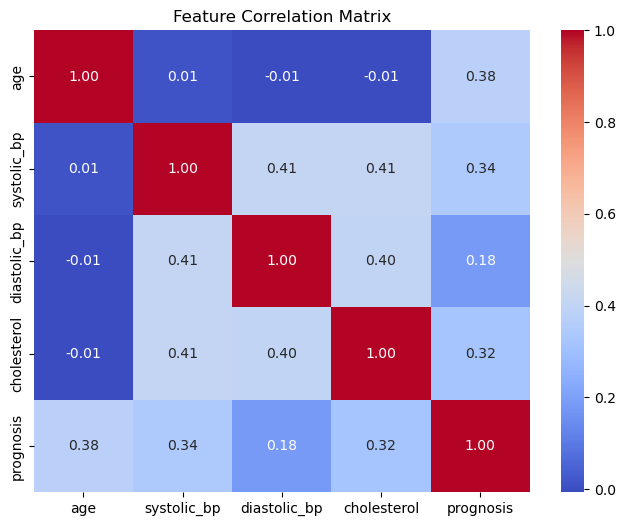

In [34]:
# 12) Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


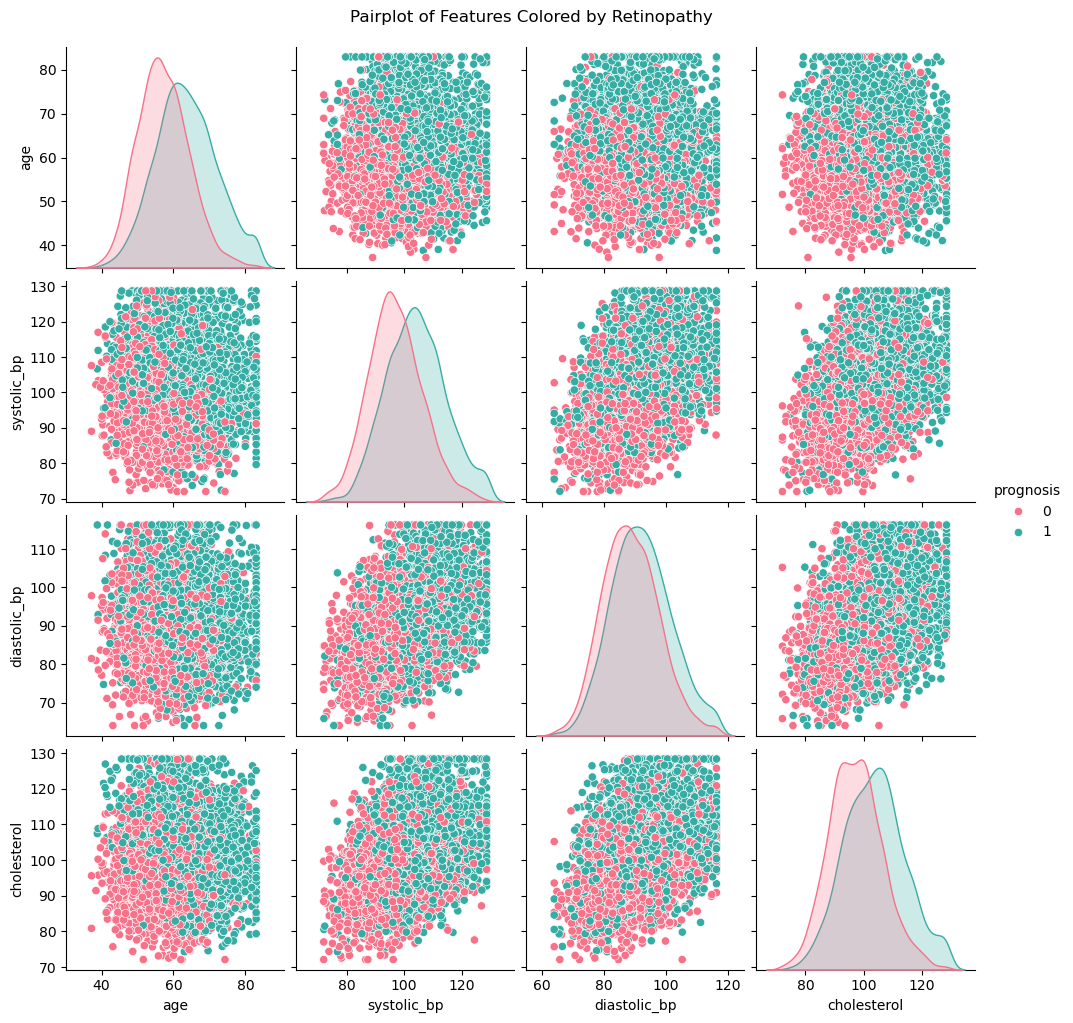

prognosis
1    0.5145
0    0.4855
Name: proportion, dtype: float64

In [35]:
# 13)  Pairplot shows relationships between features
selected_features = ['age','systolic_bp','diastolic_bp','cholesterol','prognosis']
# include prognosis for hue
sns.pairplot(df[selected_features], hue='prognosis', diag_kind='kde', palette='husl')
plt.suptitle("Pairplot of Features Colored by Retinopathy", y=1.02)
plt.show()

# 14) Class Imbalance Check (Important)
df['prognosis'].value_counts(normalize=True)

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import *
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, accuracy_score, confusion_matrix, classification_report

# Features and Target
X = df.drop('prognosis', axis=1)
y = df['prognosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1) Model Initialization and Training models
# Initialize Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [37]:
# Train XGBoost model
xgb_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,eval_metric="logloss",random_state=42)

xgb_model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
# Train SVM model
svm_model = SVC(kernel='rbf',C=1,probability=True,random_state=42)

svm_model.fit(X_train_scaled, y_train)

SVC(C=1, probability=True, random_state=42)

In [39]:
# Train model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

GaussianNB()


 logistic regression Model 
Accuracy: 0.7458333333333333
Precision: 0.7597402597402597
Recall: 0.7488
F1 Score: 0.7542304593070105
ROC-AUC Score: 0.8284271304347826
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       575
           1       0.76      0.75      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200


 XGBoost Model 
Accuracy: 0.7458333333333333
Precision: 0.7515723270440252
Recall: 0.7648
F1 Score: 0.7581284694686756
ROC-AUC: 0.8249182608695651
              precision    recall  f1-score   support

           0       0.74      0.73      0.73       575
           1       0.75      0.76      0.76       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200


  SVM Model 
Accuracy: 0.749166

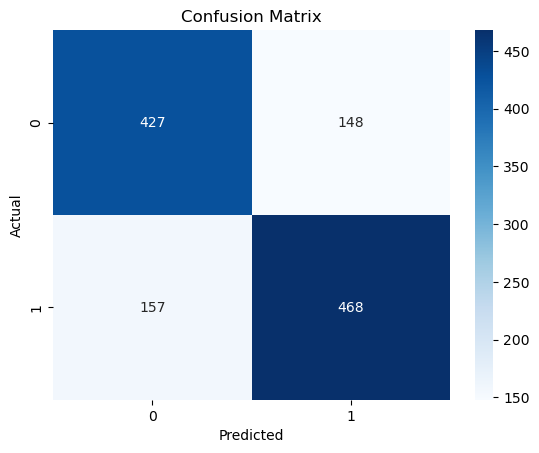

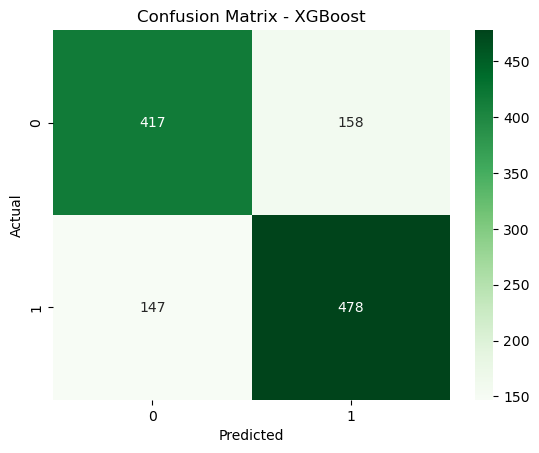

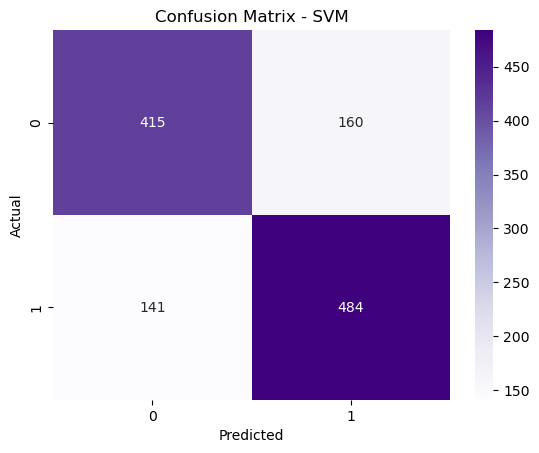

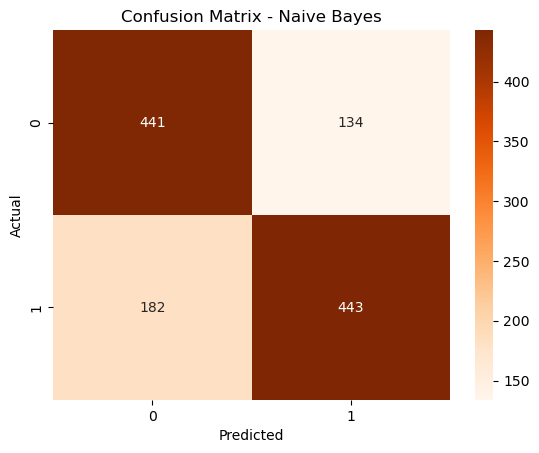

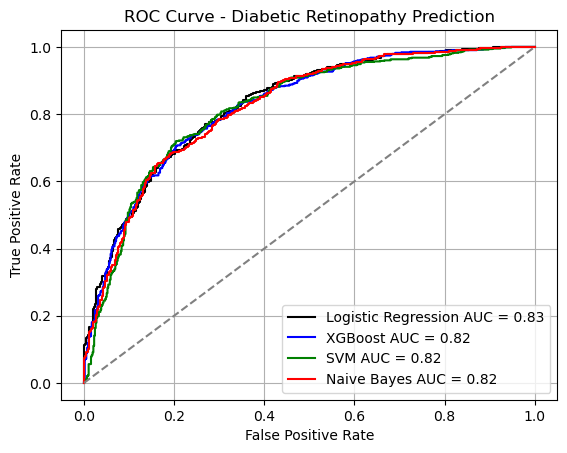

In [40]:
# 2) Predictions for all models
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

# XGBoost predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# SVM predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

# Predictions
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:,1]

# 3)  Model  Evaluation 
print("\n logistic regression Model ")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

print("\n XGBoost Model ")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

print("\n  SVM Model ")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))
print(classification_report(y_test, y_pred_svm))

print("\n Naive Bayes Model ")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nb))
print(classification_report(y_test, y_pred_nb))

# 4)  Confusion matrix 
#  logistic model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")        
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#xgbost model
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# svm model
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

# naive bayes model
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_test_scaled)[:,1]

# 5) Calculate ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_prob)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_xgb)
fpr3, tpr3, _ = roc_curve(y_test, y_prob_svm)
fpr4, tpr4, _ = roc_curve(y_test, y_prob_nb)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

# ROC for XGBoost
fpr2, tpr2, _ = roc_curve(y_test, y_prob_xgb)
auc2 = roc_auc_score(y_test, y_prob_xgb)

# Roc for svm 
auc3 = roc_auc_score(y_test, y_prob_svm)

# ROC for naive bayes
auc4 = roc_auc_score(y_test, y_prob_nb)



# Plot ROC Curve
# ROC Curves
plt.plot(fpr, tpr, color='black', label=f'Logistic Regression AUC = {auc_score:.2f}')
plt.plot(fpr2, tpr2, color='blue', label=f'XGBoost AUC = {auc2:.2f}')
plt.plot(fpr3, tpr3, color='green', label=f'SVM AUC = {auc3:.2f}')
plt.plot(fpr4, tpr4, color='red', label=f'Naive Bayes AUC = {auc4:.2f}')

plt.plot([0,1], [0,1], linestyle='--', color='gray')  # random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Diabetic Retinopathy Prediction")
plt.legend()
plt.grid(True)

plt.show()

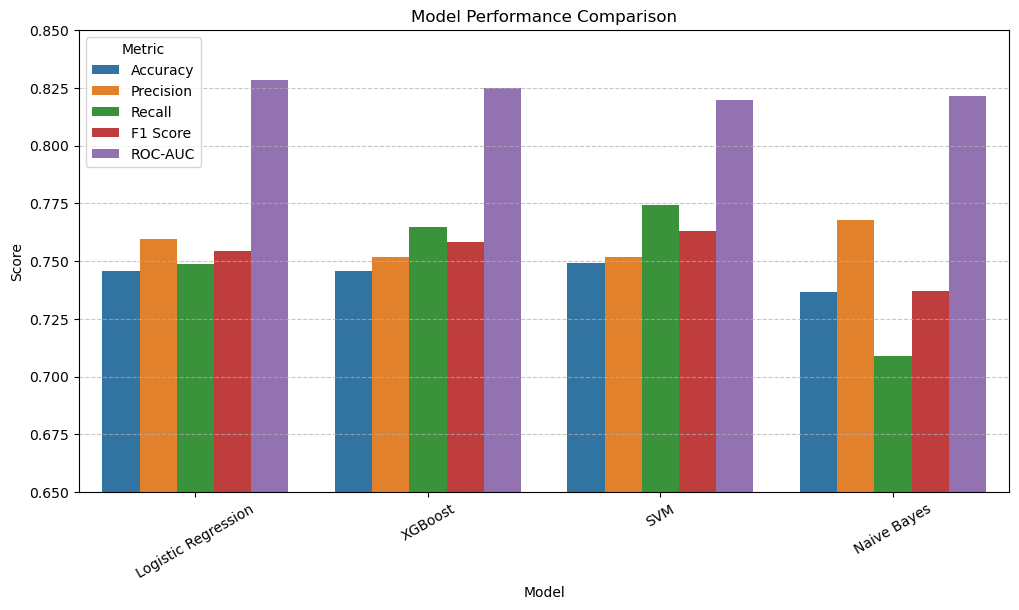

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame with all metrics
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost", "SVM", "Naive Bayes"],
    "Accuracy": [0.7458, 0.7458, 0.7492, 0.7367],
    "Precision": [0.7597, 0.7516, 0.7516, 0.7678],
    "Recall": [0.7488, 0.7648, 0.7744, 0.7088],
    "F1 Score": [0.7542, 0.7581, 0.7628, 0.7371],
    "ROC-AUC": [0.8284, 0.8249, 0.8195, 0.8215] 
})
# Melt the DataFrame for seaborn
comparison_melted = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.ylim(0.65, 0.85)
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Metric")
plt.show()

In [43]:
#Saving the Model and Scaler  Before deploying, save them using pickle:

from joblib import dump, load
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Save the model
dump(model, "logreg_model.joblib")

# Save the scaler
dump(scaler, "scaler.joblib")

['scaler.joblib']